# Monitorización de Calidad del Agua en Embalses con ndvi2gif

Este notebook demuestra cómo usar **ndvi2gif** para:

1. Cargar los embalses de la CHG (Confederación Hidrográfica del Guadalquivir) desde un asset público de Earth Engine
2. Generar composites mensuales de Sentinel-2 para detección de agua
3. Calcular máscaras de agua mensuales mediante umbrales en índices espectrales
4. Analizar índices de calidad del agua específicos de Sentinel-2
5. Visualizar la evolución temporal de la superficie de agua y parámetros de calidad

### Índices utilizados

| Índice | Descripción | Bandas S2 | Uso |
|--------|-------------|-----------|-----|
| NDWI | Normalized Difference Water Index | Green / NIR | Detección de agua |
| MNDWI | Modified NDWI | Green / SWIR1 | Detección de agua mejorada |
| AWEI | Automated Water Extraction Index | Blue, Green, NIR, SWIR1, SWIR2 | Extracción robusta de agua |
| AWEInsh | AWEI no shadow | Green, NIR, SWIR1, SWIR2 | Detección sin sombras |
| NDCI | Normalized Difference Chlorophyll Index | Red Edge 1 / Red | Clorofila-a (exclusivo S2) |
| WI2015 | Water Index 2015 | NIR, SWIR1, SWIR2 | Índice de agua adicional |


## 1. Instalación y configuración

In [1]:
pip install ndvi2gif  # Descomentar si no está instalado

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.5 MB/s eta 0:00:00
  Created wheel for pycrs: filename=PyCRS-1.0.2-py3-none-any.whl size=32686 sha256=f30c7e721ca6dc545bb34893d8e54300a3bc35837ffab9e34d7aebf8f730c1a6
  Stored in directory: /root/.cache/pip/wheels/b5/4a/72/1ba05f57ddf2cc80ad21a26512097762561d646ff3ff85f729
Successfully built pycrs
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2

In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="geemap.conversion")

import os
import ee
import geemap
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

from ndvi2gif import NdviSeasonality, TimeSeriesAnalyzer

print("Modulos importados correctamente")

# Autenticar e inicializar Earth Engine
# ee.Authenticate()  # Solo la primera vez
ee.Authenticate()
ee.Initialize(project='ee-digdgeografo')
print("Earth Engine inicializado")

Modulos importados correctamente
Earth Engine inicializado


## 2. Carga y exploración de los embalses (asset de Earth Engine)

In [8]:
# Cargar los embalses de la CHG desde un asset PÚBLICO de Earth Engine.
# Es el mismo shapefile de la CHG, subido como FeatureCollection para que
# el notebook sea reproducible sin depender de un fichero local.
asset_id = 'projects/ee-digdgeografo/assets/CHG_CaptacionesEmbalses'
embalses_fc = ee.FeatureCollection(asset_id)

# Convertir a GeoDataFrame para explorarlo con geopandas.
# El asset está en EPSG:4326; fijamos el CRS explícitamente porque
# ee_to_gdf no lo propaga.
gdf = geemap.ee_to_gdf(embalses_fc).set_crs('EPSG:4326')

print(f"Sistema de coordenadas: {gdf.crs}")
print(f"Numero de embalses: {len(gdf)}")
print(f"\nColumnas disponibles:")
print(gdf.columns.tolist())
print(f"\nPrimeras filas:")
gdf.head(10)

Sistema de coordenadas: EPSG:25830
Numero de embalses: 49

Columnas disponibles:
['id', 'Codigo', 'Codigo_SIN', 'Organismo', 'Nombre', 'Tipo', 'Perimetro_', 'Area_m2', 'geometry']

Primeras filas:


,id,Codigo,Codigo_SIN,Organismo,Nombre,Tipo,Perimetro_,Area_m2,geometry
0,100,ES050ZPROTZCCM000000060,None,None,Futura: San Clemente,Zonas de futura captación de agua para abastec...,24547.2967746013,3630060.79786837,"POLYGON ((531046.901 4193049.61, 531031.903 41..."
1,101,ES050ZPROTZCCM000000062,None,None,Futura: El Portillo,Zonas de futura captación de agua para abastec...,16489.5250446139,1220951.11664649,"POLYGON ((519778.324 4187292.638, 519776.324 4..."
2,75,ES050ZPROTZCCM000013940,13940,DEGREMONT S.A.,Víboras,Zonas de captación de agua para abastecimiento...,16601.5103253925,2096970.41945775,"POLYGON ((412366.254 4165541.988, 412355.385 4..."
3,88,ES050ZPROTZCCM000003150,3150,AYTO. DE CAZALLA DE LA SIERRA,Azuaga / Sotillo,Zonas de captación de agua para abastecimiento...,3055.80986329722,173220.107480298,"POLYGON ((255637.155 4202456.591, 255585.404 4..."
4,89,ES050ZPROTZCCM000000028,None,None,"Bolera, la",Zonas de captación de agua para abastecimiento...,25826.9451865842,2514020.06719002,"POLYGON ((508430.606 4182606.503, 508419.906 4..."
5,55,ES050ZPROTZCCM000000004,1342,"AQUALIA GESTIÓN INTEGRAL DEL AGUA, S.A.",Fresneda,Zonas de captación de agua para abastecimiento...,24629.0758985076,2049618.88043189,"POLYGON ((445379.426 4267236.658, 445383.051 4..."
6,56,ES050ZPROTZCCM000005176,5176,CONFEDERACION HIDROGRAFICA DEL GUADALQUIVIR,Guadalmena,Zonas de captación de agua para abastecimiento...,119145.141184813,13436732.6202889,"POLYGON ((509818.5 4255581.3, 509821 4255608.4..."
7,57,ES050ZPROTZCCM000003089,3089,CONFEDERACION HIDROGRAFICA DEL GUADALQUIVIR,Dañador,Zonas de captación de agua para abastecimiento...,19179.6505610431,659260.871381586,"POLYGON ((496685.3 4251641.417, 496702.8 42516..."
8,68,ES050ZPROTZCCM000000023,None,None,Aracena,Zonas de captación de agua para abastecimiento...,76067.5927304112,9326644.39812691,"POLYGON ((197002.001 4205282.324, 196999.801 4..."
9,69,ES050ZPROTZCCM000000025,None,None,Zufre,Zonas de captación de agua para abastecimiento...,117281.071882553,10045410.5803701,"POLYGON ((205296.507 4195090.792, 205284.607 4..."


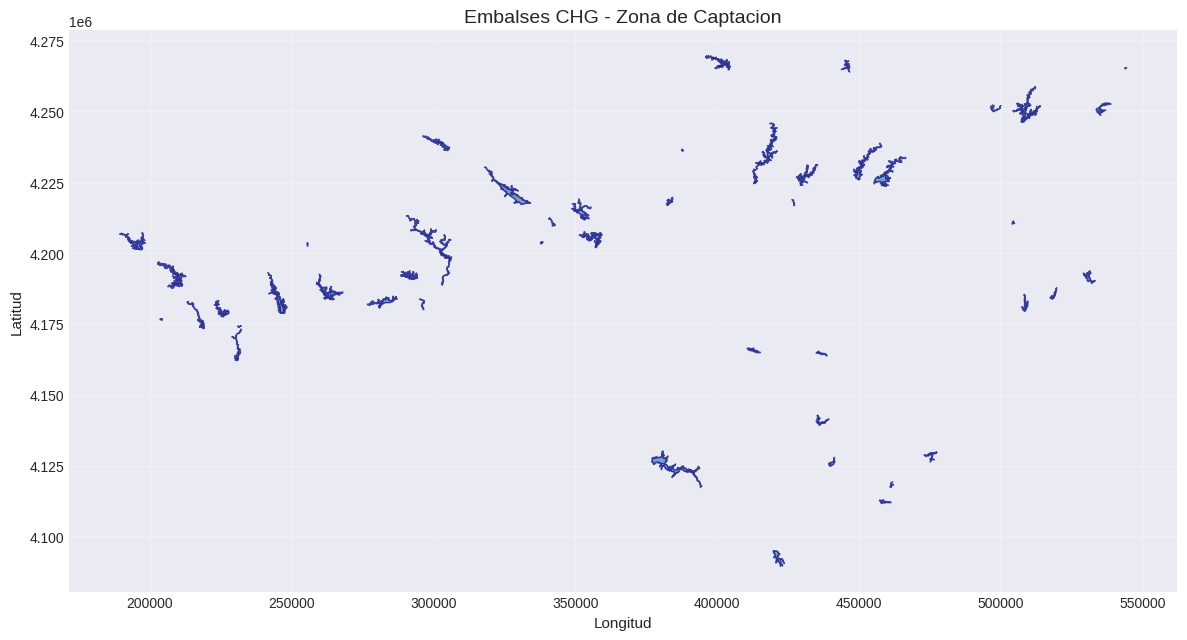


Extent total: [ 189326.03067261 4089608.96525762  544503.7058     4269589.03901556]

Estadisticas de area (m2):
count    4.900000e+01
mean     5.079071e+06
std      5.741606e+06
min      7.637545e+04
25%      6.587337e+05
50%      2.512014e+06
75%      7.361581e+06
max      2.441055e+07
Name: area_m2, dtype: float64


In [9]:
# Visualizar la distribucion geografica
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
gdf.plot(ax=ax, color='steelblue', edgecolor='navy', alpha=0.7)
ax.set_title('Embalses CHG - Zona de Captacion', fontsize=14)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.tight_layout()
plt.show()

# Informacion de los embalses
print(f"\nExtent total: {gdf.total_bounds}")
print(f"\nEstadisticas de area (m2):")
gdf['area_m2'] = gdf.geometry.to_crs('EPSG:32630').area
print(gdf['area_m2'].describe())

In [10]:
# Seleccion del embalse a analizar
# Opcion A: usar todos los embalses como ROI (union)
# Opcion B: filtrar por nombre o ID un embalse especifico

# Ver columnas que pueden contener el nombre
# Sustituir 'NOMBRE' por el nombre real de la columna que aparece arriba
nombre_col = 'Nombre'  # columna con el nombre del embalse en el asset
print("Lista de embalses disponibles:")
for i, row in gdf.iterrows():
    print(f"  [{i}] {row[nombre_col]} | Area: {row.get('area_m2', 0)/1e6:.2f} km2")

Lista de embalses disponibles:
  [0] 100 | Area: 3.63 km2
  [1] 101 | Area: 1.22 km2
  [2] 75 | Area: 2.10 km2
  [3] 88 | Area: 0.17 km2
  [4] 89 | Area: 2.51 km2
  [5] 55 | Area: 2.05 km2
  [6] 56 | Area: 13.43 km2
  [7] 57 | Area: 0.66 km2
  [8] 68 | Area: 9.34 km2
  [9] 69 | Area: 10.06 km2
  [10] 70 | Area: 5.68 km2
  [11] 71 | Area: 11.28 km2
  [12] 98 | Area: 3.84 km2
  [13] 77 | Area: 2.48 km2
  [14] 78 | Area: 24.41 km2
  [15] 80 | Area: 0.40 km2
  [16] 53 | Area: 0.08 km2
  [17] 54 | Area: 0.21 km2
  [18] 58 | Area: 4.99 km2
  [19] 59 | Area: 6.53 km2
  [20] 60 | Area: 15.41 km2
  [21] 61 | Area: 20.17 km2
  [22] 62 | Area: 1.27 km2
  [23] 63 | Area: 7.36 km2
  [24] 64 | Area: 2.18 km2
  [25] 65 | Area: 0.31 km2
  [26] 66 | Area: 11.76 km2
  [27] 90 | Area: 6.76 km2
  [28] 91 | Area: 3.45 km2
  [29] 92 | Area: 2.93 km2
  [30] 93 | Area: 5.79 km2
  [31] 94 | Area: 0.66 km2
  [32] 99 | Area: 0.08 km2
  [33] 67 | Area: 0.26 km2
  [34] 72 | Area: 0.52 km2
  [35] 73 | Area: 4.89 km

In [11]:
# Seleccionar el embalse de mayor superficie para el analisis
# (cambiar el criterio o usar filtros por nombre segun convenga)
idx_mayor = gdf['area_m2'].idxmax()
embalse_seleccionado = gdf.loc[[idx_mayor]]

print(f"Embalse seleccionado: {embalse_seleccionado.iloc[0][nombre_col]}")
print(f"Area: {embalse_seleccionado.iloc[0]['area_m2']/1e6:.2f} km2")
print(f"Coordenadas: {embalse_seleccionado.total_bounds}")

# Guardar como shapefile temporal para usarlo como ROI
embalse_path = '/tmp/embalse_seleccionado.shp'
embalse_seleccionado.to_file(embalse_path)
print(f"\nShapefile guardado en: {embalse_path}")

# Tambien podemos crear un buffer para capturar las orillas y zona de transicion
embalse_buffer = embalse_seleccionado.to_crs('EPSG:32630').buffer(500).to_crs('EPSG:4326')
embalse_buffer_gdf = gpd.GeoDataFrame(geometry=embalse_buffer, crs='EPSG:4326')
embalse_buffer_path = '/tmp/embalse_buffer.shp'
embalse_buffer_gdf.to_file(embalse_buffer_path)
print(f"Shapefile con buffer (500m) guardado en: {embalse_buffer_path}")

Embalse seleccionado: 78
Area: 24.41 km2
Coordenadas: [ 376947.2867997  4117481.00174836  394605.90985701 4130152.56584664]

Shapefile guardado en: /tmp/embalse_seleccionado.shp
Shapefile con buffer (500m) guardado en: /tmp/embalse_buffer.shp


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'area_m2' to 'area_m2_1'
  ogr_write(


## 3. Deteccion de agua: composites mensuales con NDWI y MNDWI

Usamos `periods=12` para obtener composites mensuales con Sentinel-2.

El **MNDWI** es generalmente preferible al NDWI clasico en zonas con
presencia de suelo desnudo, edificaciones y vegetacion acuatica, ya que
usa SWIR en lugar de NIR, lo que suprime mejor las areas no acuaticas.

In [12]:
# --- Composite mensual NDWI (Gao 1996) ---
# Umbral tipico para agua: NDWI > 0

s2_ndwi = NdviSeasonality(
    roi=embalse_buffer_path,   # Usamos el buffer para capturar la zona de transicion
    periods=12,                # Mensual
    start_year=2020,
    end_year=2025,
    sat='S2',
    key='median',              # Mediana para reducir ruido en agua
    index='ndwi'
)

composite_ndwi = s2_ndwi.get_year_composite()
print("Bandas NDWI mensuales:", composite_ndwi.first().bandNames().getInfo())

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Using MODIS Terra + Aqua LST (maximum coverage)
Using all Sentinel-1 orbits (ascending + descending).
Applying S1 ARD preprocessing:
  - Speckle filter: REFINED_LEE
  - Terrain correction: True
  - Terrain model: VOLUME
Sentinel-2 collection configured with cloud filtering
Year 2020: Successfully processed 12 periods using ndwi index
Year 2021: Successfully processed 12 periods using ndwi index
No data for period 3 in year 2022
No data for period 4 in year 2022
Year 2022: Successfully processed 10 periods using ndwi index
Year 2023: Successfully processed 12 periods using ndwi index
No data for period 3 in year 2024
No data for period 10 in year 2024
Year 2024: Successfully processed 10 periods using ndwi index
Year 2025: Successfully processed 12 periods using ndwi index
Bandas NDWI mensuales: ['january', 'february', 'march', 'april', 'may', 'june', 'july', 'august', 'september', 'october', 'november', 'dece

In [13]:
# --- Composite mensual MNDWI (Xu 2006) ---
# Mas robusto que NDWI en zonas con urbanizacion y vegetacion acuatica

s2_mndwi = NdviSeasonality(
    roi=embalse_buffer_path,
    periods=12,
    start_year=2020,
    end_year=2025,
    sat='S2',
    key='median',
    index='mndwi'
)

composite_mndwi = s2_mndwi.get_year_composite()
print("Bandas MNDWI mensuales:", composite_mndwi.first().bandNames().getInfo())

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Using MODIS Terra + Aqua LST (maximum coverage)
Using all Sentinel-1 orbits (ascending + descending).
Applying S1 ARD preprocessing:
  - Speckle filter: REFINED_LEE
  - Terrain correction: True
  - Terrain model: VOLUME
Sentinel-2 collection configured with cloud filtering
Year 2020: Successfully processed 12 periods using mndwi index
Year 2021: Successfully processed 12 periods using mndwi index
No data for period 3 in year 2022
No data for period 4 in year 2022
Year 2022: Successfully processed 10 periods using mndwi index
Year 2023: Successfully processed 12 periods using mndwi index
No data for period 3 in year 2024
No data for period 10 in year 2024
Year 2024: Successfully processed 10 periods using mndwi index
Year 2025: Successfully processed 12 periods using mndwi index
Bandas MNDWI mensuales: ['january', 'february', 'march', 'april', 'may', 'june', 'july', 'august', 'september', 'october', 'november'

In [15]:
# --- Composite mensual AWEI (Feyisa 2014) ---
# Algoritmo de extraccion de agua automatico, muy robusto frente a sombras

s2_awei = NdviSeasonality(
    roi=embalse_buffer_path,
    periods=12,
    start_year=2020,
    end_year=2025,
    sat='S2',
    key='median',
    index='aweinsh'            # AWEInsh: sin penalizacion por sombras, adecuado para embalses
)

composite_awei = s2_awei.get_year_composite()
print("Bandas AWEInsh mensuales:", composite_awei.first().bandNames().getInfo())

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Using MODIS Terra + Aqua LST (maximum coverage)
Using all Sentinel-1 orbits (ascending + descending).
Applying S1 ARD preprocessing:
  - Speckle filter: REFINED_LEE
  - Terrain correction: True
  - Terrain model: VOLUME
Sentinel-2 collection configured with cloud filtering
Year 2020: Successfully processed 12 periods using aweinsh index
Year 2021: Successfully processed 12 periods using aweinsh index
No data for period 3 in year 2022
No data for period 4 in year 2022
Year 2022: Successfully processed 10 periods using aweinsh index
Year 2023: Successfully processed 12 periods using aweinsh index
No data for period 3 in year 2024
No data for period 10 in year 2024
Year 2024: Successfully processed 10 periods using aweinsh index
Year 2025: Successfully processed 12 periods using aweinsh index
Bandas AWEInsh mensuales: ['january', 'february', 'march', 'april', 'may', 'june', 'july', 'august', 'september', 'octobe

## 4. Visualizacion de los composites de deteccion de agua

In [16]:
Map1 = geemap.Map()
Map1.centerObject(composite_mndwi, zoom=11)

# Parametros de visualizacion para indices de agua
# Valores positivos = agua, negativos = tierra
water_viz = {
    'bands': ['july'],
    'min': -0.3,
    'max': 0.5,
    'palette': ['#d73027', '#fc8d59', '#fee090', '#e0f3f8', '#74add1', '#313695']
}

# Comparativa entre anos: mediana de todos los anos para julio
mndwi_julio = composite_mndwi.select('july')
ndwi_julio  = composite_ndwi.select('july')
awei_julio  = composite_awei.select('july')

Map1.addLayer(ndwi_julio.median(),  water_viz, 'NDWI - Julio (mediana interanual)')
Map1.addLayer(mndwi_julio.median(), water_viz, 'MNDWI - Julio (mediana interanual)')
Map1.addLayer(awei_julio.median(),
              {'bands': ['july'], 'min': -2000, 'max': 2000,
               'palette': ['#d73027', '#fc8d59', '#fee090', '#e0f3f8', '#74add1', '#313695']},
              'AWEInsh - Julio (mediana interanual)')

Map1

Map(center=[37.259713781436105, -4.2969655767737365], controls=(WidgetControl(options=['position', 'transparen…

## 5. Mascaras binarias de agua

Aplicamos un umbral para generar mascaras binarias:
- **MNDWI > 0**: agua (valor 1)
- **MNDWI <= 0**: no-agua (valor 0)

Este umbral funciona bien en la mayoria de embalses ibericos. En zonas
muy turbias puede requerir ajuste (p.ej. MNDWI > 0.1).

In [17]:
# Umbral para mascara binaria
WATER_THRESHOLD = 0.0  # Ajustar si es necesario (tipicamente 0.0 a 0.1)

MESES = ['january', 'february', 'march', 'april', 'may', 'june',
         'july', 'august', 'september', 'october', 'november', 'december']

def crear_mascara_agua(composite, threshold=WATER_THRESHOLD):
    """Convierte un composite de indice de agua en mascara binaria.

    Devuelve una ImageCollection donde cada imagen tiene bandas
    mensuales con valor 1 (agua) o 0 (no-agua).
    """
    def mask_image(image):
        return image.gt(threshold).rename(image.bandNames())
    return composite.map(mask_image)

mascaras_agua = crear_mascara_agua(composite_mndwi)

# Comprobar resultado
primera_img = mascaras_agua.first()
print("Bandas de mascara:", primera_img.bandNames().getInfo())
print("Valores unicos (deberia ser 0 y 1):")
stats = primera_img.select('july').reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=primera_img.geometry(),
    scale=20,
    maxPixels=1e8
).getInfo()
print(stats)

Bandas de mascara: ['january', 'february', 'march', 'april', 'may', 'june', 'july', 'august', 'september', 'october', 'november', 'december']
Valores unicos (deberia ser 0 y 1):
{'july': {'0': 170760.52941176444, '1': 40533}}


In [18]:
Map2 = geemap.Map()
Map2.centerObject(composite_mndwi, zoom=11)

mascara_viz = {
    'bands': ['july'],
    'min': 0,
    'max': 1,
    'palette': ['#f5f5f5', '#2166ac']  # blanco = tierra, azul = agua
}

# Mascara de agua para diferentes meses con la mediana interanual
for mes in ['january', 'april', 'july', 'october']:
    mascara_mes = mascaras_agua.select(mes).median()
    Map2.addLayer(
        mascara_mes,
        {'bands': [mes], 'min': 0, 'max': 1, 'palette': ['#f5f5f5', '#2166ac']},
        f'Mascara agua - {mes.capitalize()}'
    )

Map2

Map(center=[37.259713781436105, -4.2969655767737365], controls=(WidgetControl(options=['position', 'transparen…

## 6. Calculo de superficie de agua mensual

Calculamos la superficie inundada en km2 para cada mes y cada año.

In [45]:
resultados = []
imagenes = mascaras_agua.toList(mascaras_agua.size())
years = list(range(s2_mndwi.start_year, s2_mndwi.end_year + 1))

for i, year in enumerate(years):
    img = ee.Image(imagenes.get(i))
    sumas = img.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=s2_mndwi.roi,
        scale=10,
        maxPixels=1e9
    ).getInfo()
    print(f"{year}: {len(sumas)} meses")
    for mes in MESES:
        suma = sumas.get(mes)
        if suma is not None:
            area_km2 = suma * 10 / 1e6
            resultados.append({'year': year, 'month': mes, 'area_km2': area_km2})

df_area = pd.DataFrame(resultados)
print(f"Total registros: {len(df_area)}")
df_area.head()


2020: 12 meses
2021: 12 meses
2022: 10 meses
2023: 12 meses
2024: 10 meses
2025: 12 meses
Total registros: 68


,year,month,area_km2
0,2020,january,1.768350
1,2020,february,1.760554
2,2020,march,1.870191
3,2020,april,1.771224
4,2020,may,1.895030


In [38]:
img = ee.Image(mascaras_agua.toList(1).get(0))
print("Bandas:", img.bandNames().getInfo())

sumas = img.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=s2_mndwi.roi,
    scale=10,
    maxPixels=1e9
).getInfo()
print("Sumas:", sumas)


Bandas: ['january', 'february', 'march', 'april', 'may', 'june', 'july', 'august', 'september', 'october', 'november', 'december']
Sumas: {'april': 177122.36078431373, 'august': 142090, 'december': 96908.76862745096, 'february': 176055.36078431373, 'january': 176835.02352941173, 'july': 162221, 'june': 176939, 'march': 187019.0705882353, 'may': 189503, 'november': 130032.98039215687, 'october': 126978.62745098039, 'september': 131691}


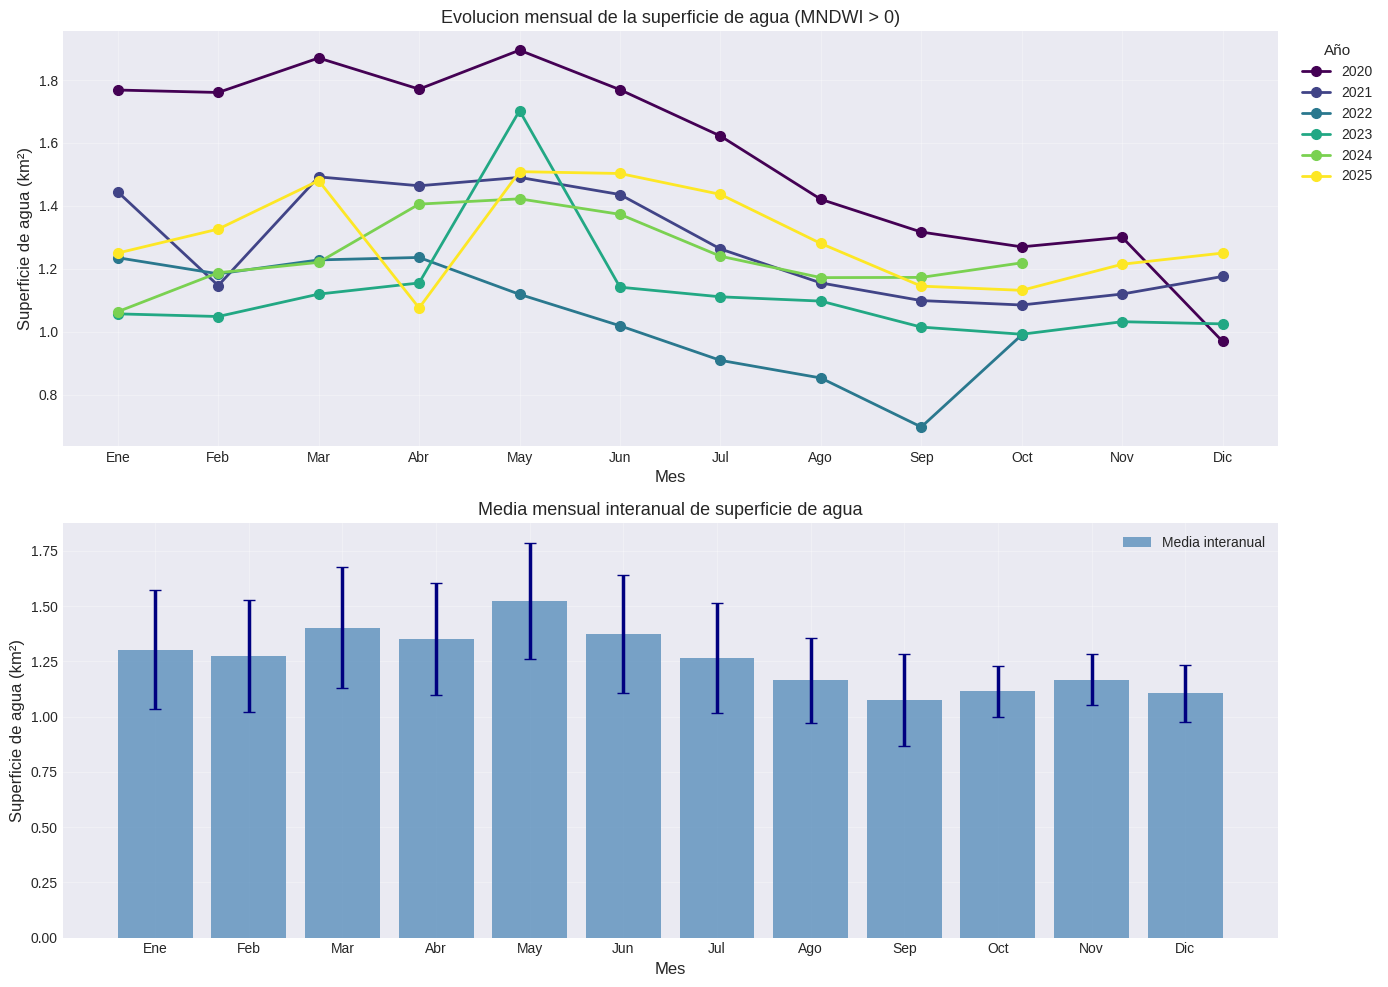

Figura guardada: superficie_agua_mensual.png


In [46]:
# Ordenar meses correctamente para el grafico
orden_meses = {'january':1,'february':2,'march':3,'april':4,'may':5,'june':6,
               'july':7,'august':8,'september':9,'october':10,'november':11,'december':12}
df_area['month_num'] = df_area['month'].map(orden_meses)
df_area = df_area.sort_values(['year', 'month_num'])

# --- Grafico de evolucion mensual por año ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Series temporales por año
ax1 = axes[0]
colores = plt.cm.viridis(np.linspace(0, 1, df_area['year'].nunique()))
for (año, grupo), color in zip(df_area.groupby('year'), colores):
    ax1.plot(grupo['month_num'], grupo['area_km2'],
             marker='o', linewidth=2, label=str(año), color=color)
ax1.set_xlabel('Mes', fontsize=12)
ax1.set_ylabel('Superficie de agua (km²)', fontsize=12)
ax1.set_title('Evolucion mensual de la superficie de agua (MNDWI > 0)', fontsize=13)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                      'Jul','Ago','Sep','Oct','Nov','Dic'])
ax1.legend(title='Año', bbox_to_anchor=(1.01, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Media mensual con desviacion estandar
ax2 = axes[1]
media_mensual = df_area.groupby('month_num')['area_km2'].agg(['mean', 'std']).reset_index()
ax2.bar(media_mensual['month_num'], media_mensual['mean'],
        color='steelblue', alpha=0.7, label='Media interanual')
ax2.errorbar(media_mensual['month_num'], media_mensual['mean'],
             yerr=media_mensual['std'], fmt='none', color='navy', capsize=4)
ax2.set_xlabel('Mes', fontsize=12)
ax2.set_ylabel('Superficie de agua (km²)', fontsize=12)
ax2.set_title('Media mensual interanual de superficie de agua', fontsize=13)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                      'Jul','Ago','Sep','Oct','Nov','Dic'])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('superficie_agua_mensual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: superficie_agua_mensual.png")

## 7. Indices de calidad del agua con Sentinel-2

### NDCI - Normalized Difference Chlorophyll Index

El NDCI usa la banda **Red Edge 1 (B5, 705 nm)** exclusiva de Sentinel-2,
optimizada para detectar clorofila-a y cianobacterias en aguas continentales.

**Formula:** `(B5 - B4) / (B5 + B4)`

- Valores altos (> 0.1): alta concentracion de clorofila, posibles floraciones algales
- Valores bajos (< 0): agua con baja productividad biologica

**Referencia:** Mishra & Mishra (2012), Remote Sensing of Environment

In [47]:
# NDCI mensual - solo disponible para Sentinel-2 (usa Red Edge B5)
s2_ndci = NdviSeasonality(
    roi=embalse_buffer_path,
    periods=12,
    start_year=2020,
    end_year=2025,
    sat='S2',
    key='median',
    index='ndci'       # Normalized Difference Chlorophyll Index - exclusivo S2
)

composite_ndci = s2_ndci.get_year_composite()
print("Bandas NDCI mensuales:", composite_ndci.first().bandNames().getInfo())

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Using MODIS Terra + Aqua LST (maximum coverage)
Using all Sentinel-1 orbits (ascending + descending).
Applying S1 ARD preprocessing:
  - Speckle filter: REFINED_LEE
  - Terrain correction: True
  - Terrain model: VOLUME
Sentinel-2 collection configured with cloud filtering
Year 2020: Successfully processed 12 periods using ndci index
Year 2021: Successfully processed 12 periods using ndci index
No data for period 3 in year 2022
No data for period 4 in year 2022
Year 2022: Successfully processed 10 periods using ndci index
Year 2023: Successfully processed 12 periods using ndci index
No data for period 3 in year 2024
No data for period 10 in year 2024
Year 2024: Successfully processed 10 periods using ndci index
Year 2025: Successfully processed 12 periods using ndci index
Bandas NDCI mensuales: ['january', 'february', 'march', 'april', 'may', 'june', 'july', 'august', 'september', 'october', 'november', 'dece

In [48]:
# WI2015 - Water Index 2015 como indice adicional de agua
s2_wi2015 = NdviSeasonality(
    roi=embalse_buffer_path,
    periods=12,
    start_year=2020,
    end_year=2025,
    sat='S2',
    key='median',
    index='wi2015'
)

composite_wi2015 = s2_wi2015.get_year_composite()
print("Bandas WI2015 mensuales:", composite_wi2015.first().bandNames().getInfo())

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Using MODIS Terra + Aqua LST (maximum coverage)
Using all Sentinel-1 orbits (ascending + descending).
Applying S1 ARD preprocessing:
  - Speckle filter: REFINED_LEE
  - Terrain correction: True
  - Terrain model: VOLUME
Sentinel-2 collection configured with cloud filtering
Year 2020: Successfully processed 12 periods using wi2015 index
Year 2021: Successfully processed 12 periods using wi2015 index
No data for period 3 in year 2022
No data for period 4 in year 2022
Year 2022: Successfully processed 10 periods using wi2015 index
Year 2023: Successfully processed 12 periods using wi2015 index
No data for period 3 in year 2024
No data for period 10 in year 2024
Year 2024: Successfully processed 10 periods using wi2015 index
Year 2025: Successfully processed 12 periods using wi2015 index
Bandas WI2015 mensuales: ['january', 'february', 'march', 'april', 'may', 'june', 'july', 'august', 'september', 'october', 'no

## 8. Calidad del agua: NDCI solo sobre pixeles de agua

Para analizar correctamente la calidad del agua, aplicamos la mascara
de agua (MNDWI > 0) antes de interpretar el NDCI.

In [49]:
def aplicar_mascara_agua_a_indice(composite_indice, composite_mascara, threshold=0.0):
    """
    Enmascara un composite de indice de calidad de agua
    usando solo los pixeles identificados como agua.
    """
    def mask_per_image(args):
        img_indice  = ee.Image(ee.List(args).get(0))
        img_mascara = ee.Image(ee.List(args).get(1))
        mascara_binaria = img_mascara.gt(threshold)
        return img_indice.updateMask(mascara_binaria)

    lista_indice  = composite_indice.toList(composite_indice.size())
    lista_mascara = composite_mascara.toList(composite_mascara.size())

    # Asegurar que ambas colecciones tienen el mismo tamanyo
    n = composite_indice.size().min(composite_mascara.size())
    indices = ee.List.sequence(0, n.subtract(1))

    masked = indices.map(
        lambda i: ee.Image(lista_indice.get(i))
                    .updateMask(ee.Image(lista_mascara.get(i)).gt(threshold))
    )
    return ee.ImageCollection(masked)

composite_ndci_masked = aplicar_mascara_agua_a_indice(composite_ndci, composite_mndwi)
print("NDCI enmascarado sobre agua calculado")

NDCI enmascarado sobre agua calculado


In [50]:
# Visualizacion comparativa: NDWI, MNDWI, NDCI
Map3 = geemap.Map()
Map3.centerObject(composite_ndci, zoom=11)

# Palette para indices de agua (NDWI/MNDWI)
water_palette = ['#d73027', '#fc8d59', '#fee090', '#e0f3f8', '#74add1', '#313695']

# Palette para clorofila (NDCI): rojo = baja, verde = alta concentracion
chl_palette = ['#053061', '#2166ac', '#4393c3', '#92c5de', '#d1e5f0',
               '#f7f7f7', '#fddbc7', '#f4a582', '#d6604d', '#b2182b', '#67001f']

# Mediana interanual para julio (mes de maxima radiacion, mayor riesgo de floracion)
mes_analisis = 'july'

Map3.addLayer(
    composite_mndwi.select(mes_analisis).median(),
    {'bands': [mes_analisis], 'min': -0.3, 'max': 0.6, 'palette': water_palette},
    f'MNDWI - {mes_analisis.capitalize()}'
)
Map3.addLayer(
    composite_ndci_masked.select(mes_analisis).median(),
    {'bands': [mes_analisis], 'min': -0.2, 'max': 0.3, 'palette': chl_palette},
    f'NDCI (clorofila-a) - {mes_analisis.capitalize()}'
)
Map3.addLayer(
    composite_wi2015.select(mes_analisis).median(),
    {'bands': [mes_analisis], 'min': -0.5, 'max': 0.5, 'palette': water_palette},
    f'WI2015 - {mes_analisis.capitalize()}'
)

Map3

Map(center=[37.259713781436105, -4.2969655767737365], controls=(WidgetControl(options=['position', 'transparen…

## 9. Analisis temporal de la calidad del agua

Extraemos la media mensual del NDCI sobre los pixeles de agua
para monitorizar la evolucion de la clorofila-a a lo largo del tiempo.

In [54]:
def extraer_estadisticas_mensuales(composite, roi_geom, banda_base, scale=20):
    """
    Extrae media, mediana y desviacion tipica de un composite mensual
    para cada imagen (año) de la coleccion.

    Returns
    -------
    pd.DataFrame con columnas [year, month, mean, median, std]
    """
    resultados = []
    imagenes = composite.toList(composite.size())

    reducers = (
        ee.Reducer.mean()
        .combine(ee.Reducer.median(), sharedInputs=True)
        .combine(ee.Reducer.stdDev(), sharedInputs=True)
    )

    for i, year in enumerate(years):
        img = ee.Image(imagenes.get(i))
        stats = img.reduceRegion(
            reducer=reducers,
            geometry=roi_geom,
            scale=scale,
            maxPixels=1e9
        ).getInfo()

        for mes in MESES:
            resultados.append({
                'year':   year,
                'month':  mes,
                'mean':   stats.get(f'{mes}_mean'),
                'median': stats.get(f'{mes}_median'),
                'std':    stats.get(f'{mes}_stdDev')
            })

    df = pd.DataFrame(resultados)
    df['month_num'] = df['month'].map(orden_meses)
    return df.sort_values(['year', 'month_num'])

years = list(range(s2_ndci.start_year, s2_ndci.end_year + 1))

df_ndci = extraer_estadisticas_mensuales(composite_ndci_masked, s2_ndci.roi, years)
print(f"Extraidos {len(df_ndci)} registros")
df_ndci.head(12)

Extraidos 72 registros


,year,month,mean,median,std,month_num
0,2020,january,-0.129114,-0.160314,0.107131,1
1,2020,february,-0.066698,-0.105500,0.159010,2
2,2020,march,-0.071482,-0.105594,0.126903,3
3,2020,april,-0.139755,-0.160205,0.237251,4
4,2020,may,-0.023656,-0.105674,0.216044,5
5,2020,june,-0.063485,-0.058550,0.109162,6
6,2020,july,0.016121,0.005829,0.045317,7
7,2020,august,0.017547,0.000523,0.114532,8
8,2020,september,-0.077026,-0.050624,0.185264,9
9,2020,october,-0.202910,-0.198987,0.201096,10


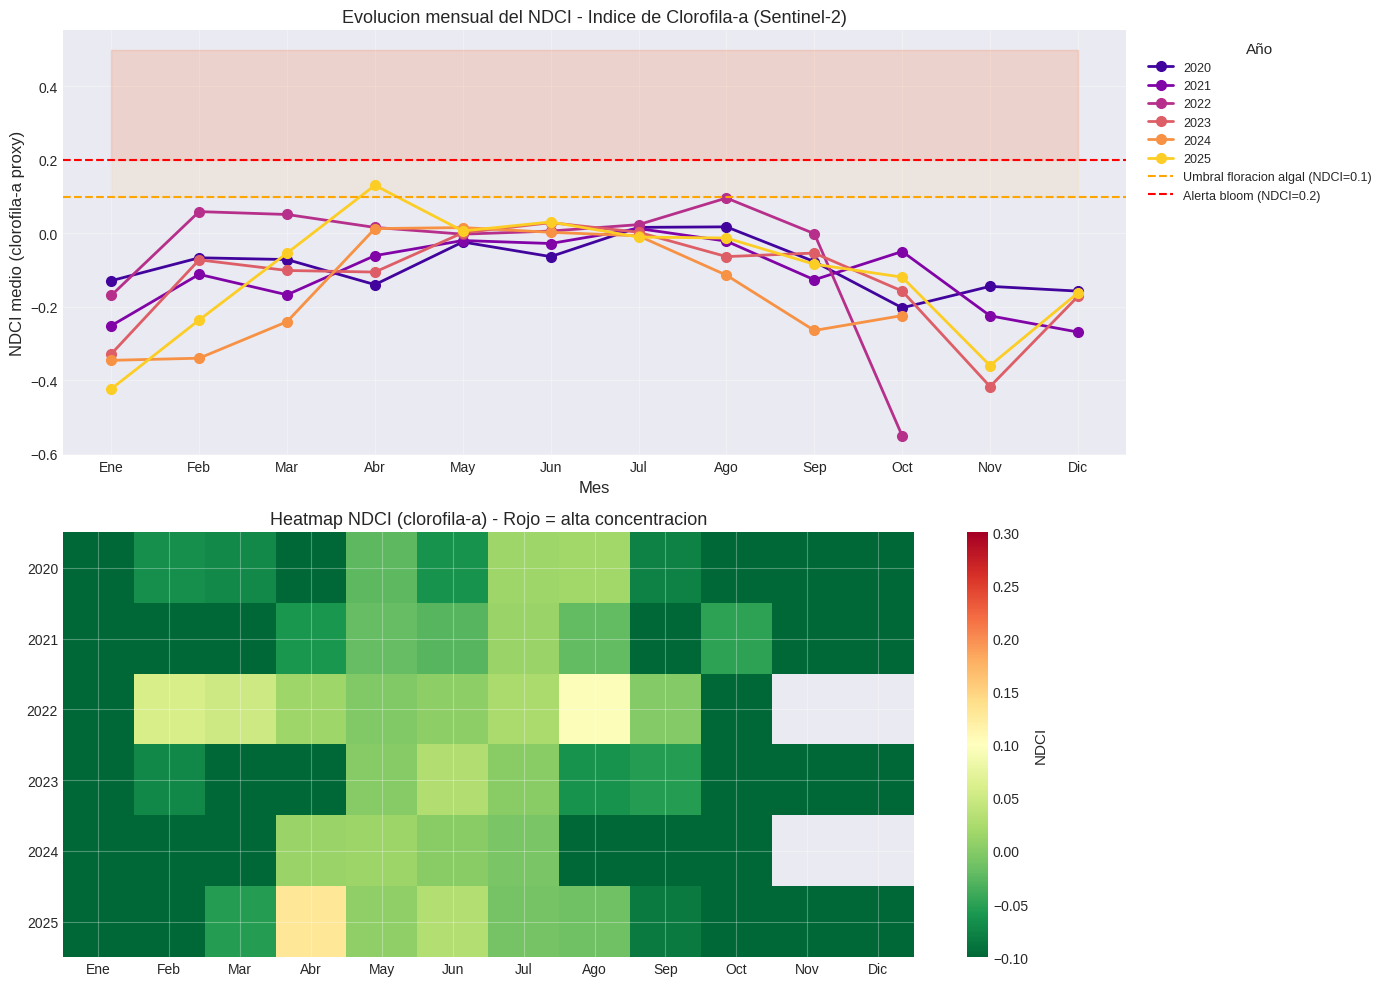

Figura guardada: ndci_calidad_agua.png


In [55]:
# --- Grafico de calidad del agua: NDCI mensual ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: NDCI mensual por año (proxy de clorofila-a)
ax1 = axes[0]
colores = plt.cm.plasma(np.linspace(0.1, 0.9, df_ndci['year'].nunique()))
for (año, grupo), color in zip(df_ndci.groupby('year'), colores):
    ax1.plot(grupo['month_num'], grupo['mean'],
             marker='o', linewidth=2, label=str(año), color=color)

# Zona de alerta (NDCI > 0.1 -> posible floracion algal)
ax1.axhline(0.1, color='orange', linestyle='--', linewidth=1.5,
            label='Umbral floracion algal (NDCI=0.1)')
ax1.axhline(0.2, color='red', linestyle='--', linewidth=1.5,
            label='Alerta bloom (NDCI=0.2)')
ax1.fill_between(range(1, 13), 0.1, 0.5, alpha=0.08, color='orange')
ax1.fill_between(range(1, 13), 0.2, 0.5, alpha=0.08, color='red')

ax1.set_xlabel('Mes', fontsize=12)
ax1.set_ylabel('NDCI medio (clorofila-a proxy)', fontsize=12)
ax1.set_title('Evolucion mensual del NDCI - Indice de Clorofila-a (Sentinel-2)', fontsize=13)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                      'Jul','Ago','Sep','Oct','Nov','Dic'])
ax1.legend(title='Año', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Heatmap anyo x mes del NDCI
ax2 = axes[1]
pivot = df_ndci.pivot(index='year', columns='month_num', values='mean')
pivot.columns = ['Ene','Feb','Mar','Abr','May','Jun',
                  'Jul','Ago','Sep','Oct','Nov','Dic']
im = ax2.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r',
                vmin=-0.1, vmax=0.3)
ax2.set_xticks(range(12))
ax2.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                      'Jul','Ago','Sep','Oct','Nov','Dic'])
ax2.set_yticks(range(len(pivot.index)))
ax2.set_yticklabels(pivot.index)
ax2.set_title('Heatmap NDCI (clorofila-a) - Rojo = alta concentracion', fontsize=13)
plt.colorbar(im, ax=ax2, label='NDCI')

plt.tight_layout()
plt.savefig('ndci_calidad_agua.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: ndci_calidad_agua.png")

## 10. Analisis con TimeSeriesAnalyzer

Usamos el modulo `TimeSeriesAnalyzer` para detectar tendencias
en la evolucion de la clorofila-a (NDCI) a lo largo del periodo.

In [58]:
# Analisis de tendencias con TimeSeriesAnalyzer
ts_ndci = ts_ndci = TimeSeriesAnalyzer(s2_ndci)

# Extraer serie temporal
ts_data = ts_ndci.extract_time_series(
    #geometry=roi_ee,
    reducer='mean',
    scale=20
)
print("Serie temporal extraida:")
print(ts_data.head())

Using ROI centroid: [-4.296965576773845, 37.25971378143628]
Extracting 72 temporal periods...

Successfully extracted 68 data points
Serie temporal extraida:
                 date     value  year    period  doy  season  month
0 2020-01-16 00:00:00  0.099055  2020   january   16  winter      1
1 2020-02-14 12:00:00  0.099726  2020  february   45  winter      2
2 2020-03-16 00:00:00  0.106423  2020     march   76  spring      3
3 2020-04-15 12:00:00  0.108484  2020     april  106  spring      4
4 2020-05-16 00:00:00  0.081064  2020       may  137  spring      5


In [61]:
# Estadisticas de tendencia
trend = ts_ndci.analyze_trend()
print(trend)
print("=== Tendencia en NDCI (clorofila-a) ===")
mk = trend['mann_kendall']
print(f"tau={mk['tau']:.3f}, p-value={mk['p_value']:.4f}")
print(trend['interpretation'])


Using cached time series data
{'mann_kendall': {'trend': 1.0, 'tau': 0.10798946444249341, 'z_score': 1.2968833747053339, 'p_value': 0.19467131767226298, 's_statistic': 246.0, 'var_s': 35688.666666666664}, 'interpretation': 'No significant trend (p=0.195)'}
=== Tendencia en NDCI (clorofila-a) ===
tau=0.108, p-value=0.1947
No significant trend (p=0.195)


Using cached time series data
Year 2020: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=35.0%, EOS=60.0%
EOS found at day 45.0
Season too short (-275.0 days), skipping
Year 2021: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=35.0%, EOS=60.0%
EOS found at day 45.0
Season too short (-274.0 days), skipping
Year 2022: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=35.0%, EOS=60.0%
No EOS detected with current criteria
Year 2023: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=35.0%, EOS=60.0%
EOS found at day 45.0
Year 2024: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=35.0%, EOS=60.0%
EOS found at day 106.0
Season too short (-153.0 days), skipping
Year 2025: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=35.0%, EOS=60.0%
No EOS detected with current criteria

PHENOLOGY EXTRACTION SUMMARY:
Method: threshold
Success rate: 3/6 (50.0%)


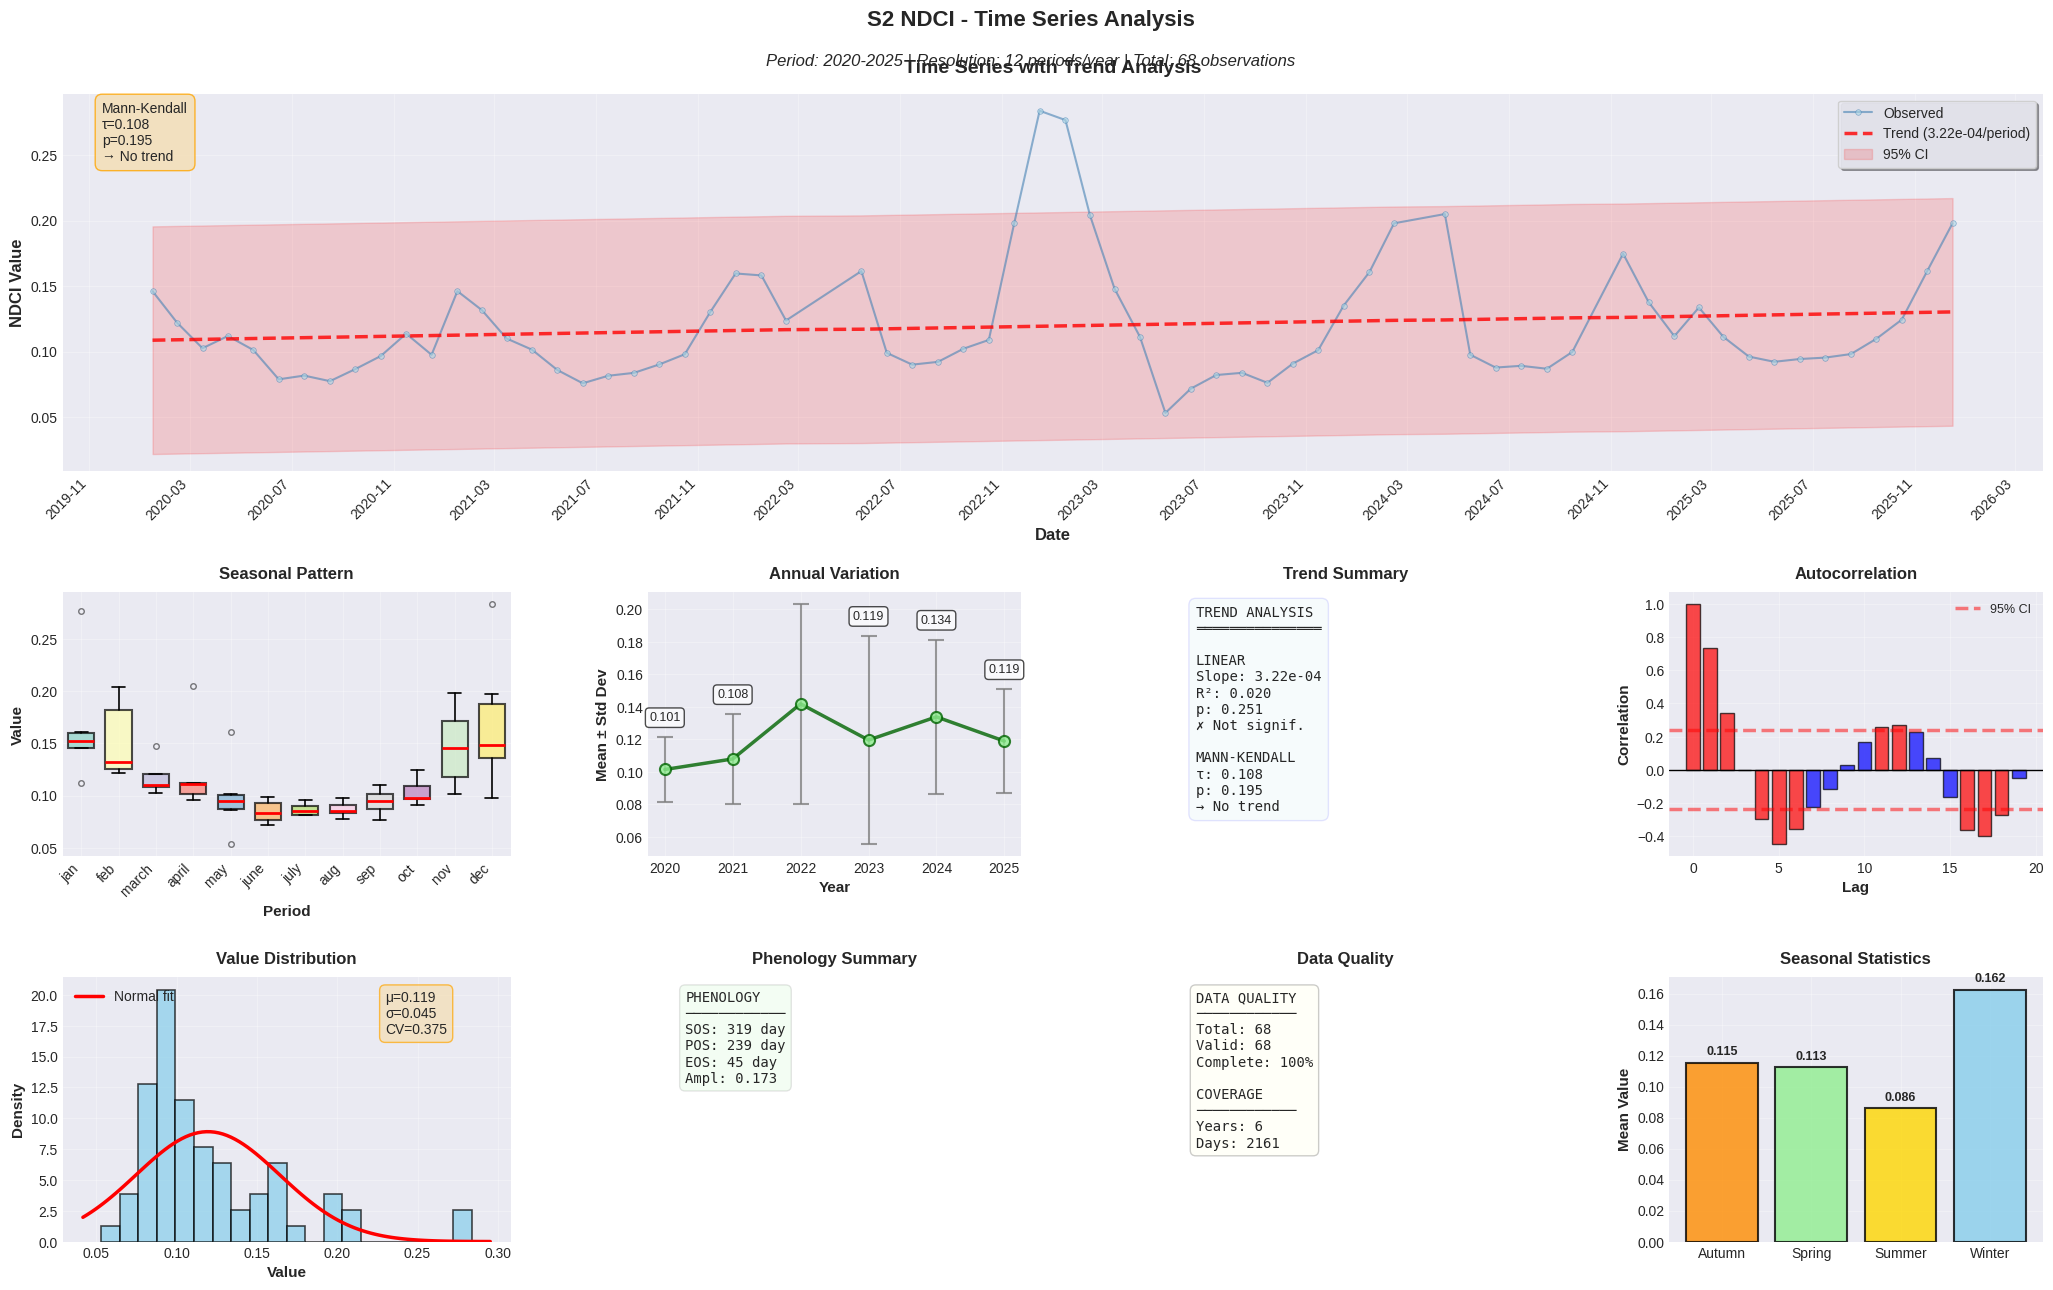

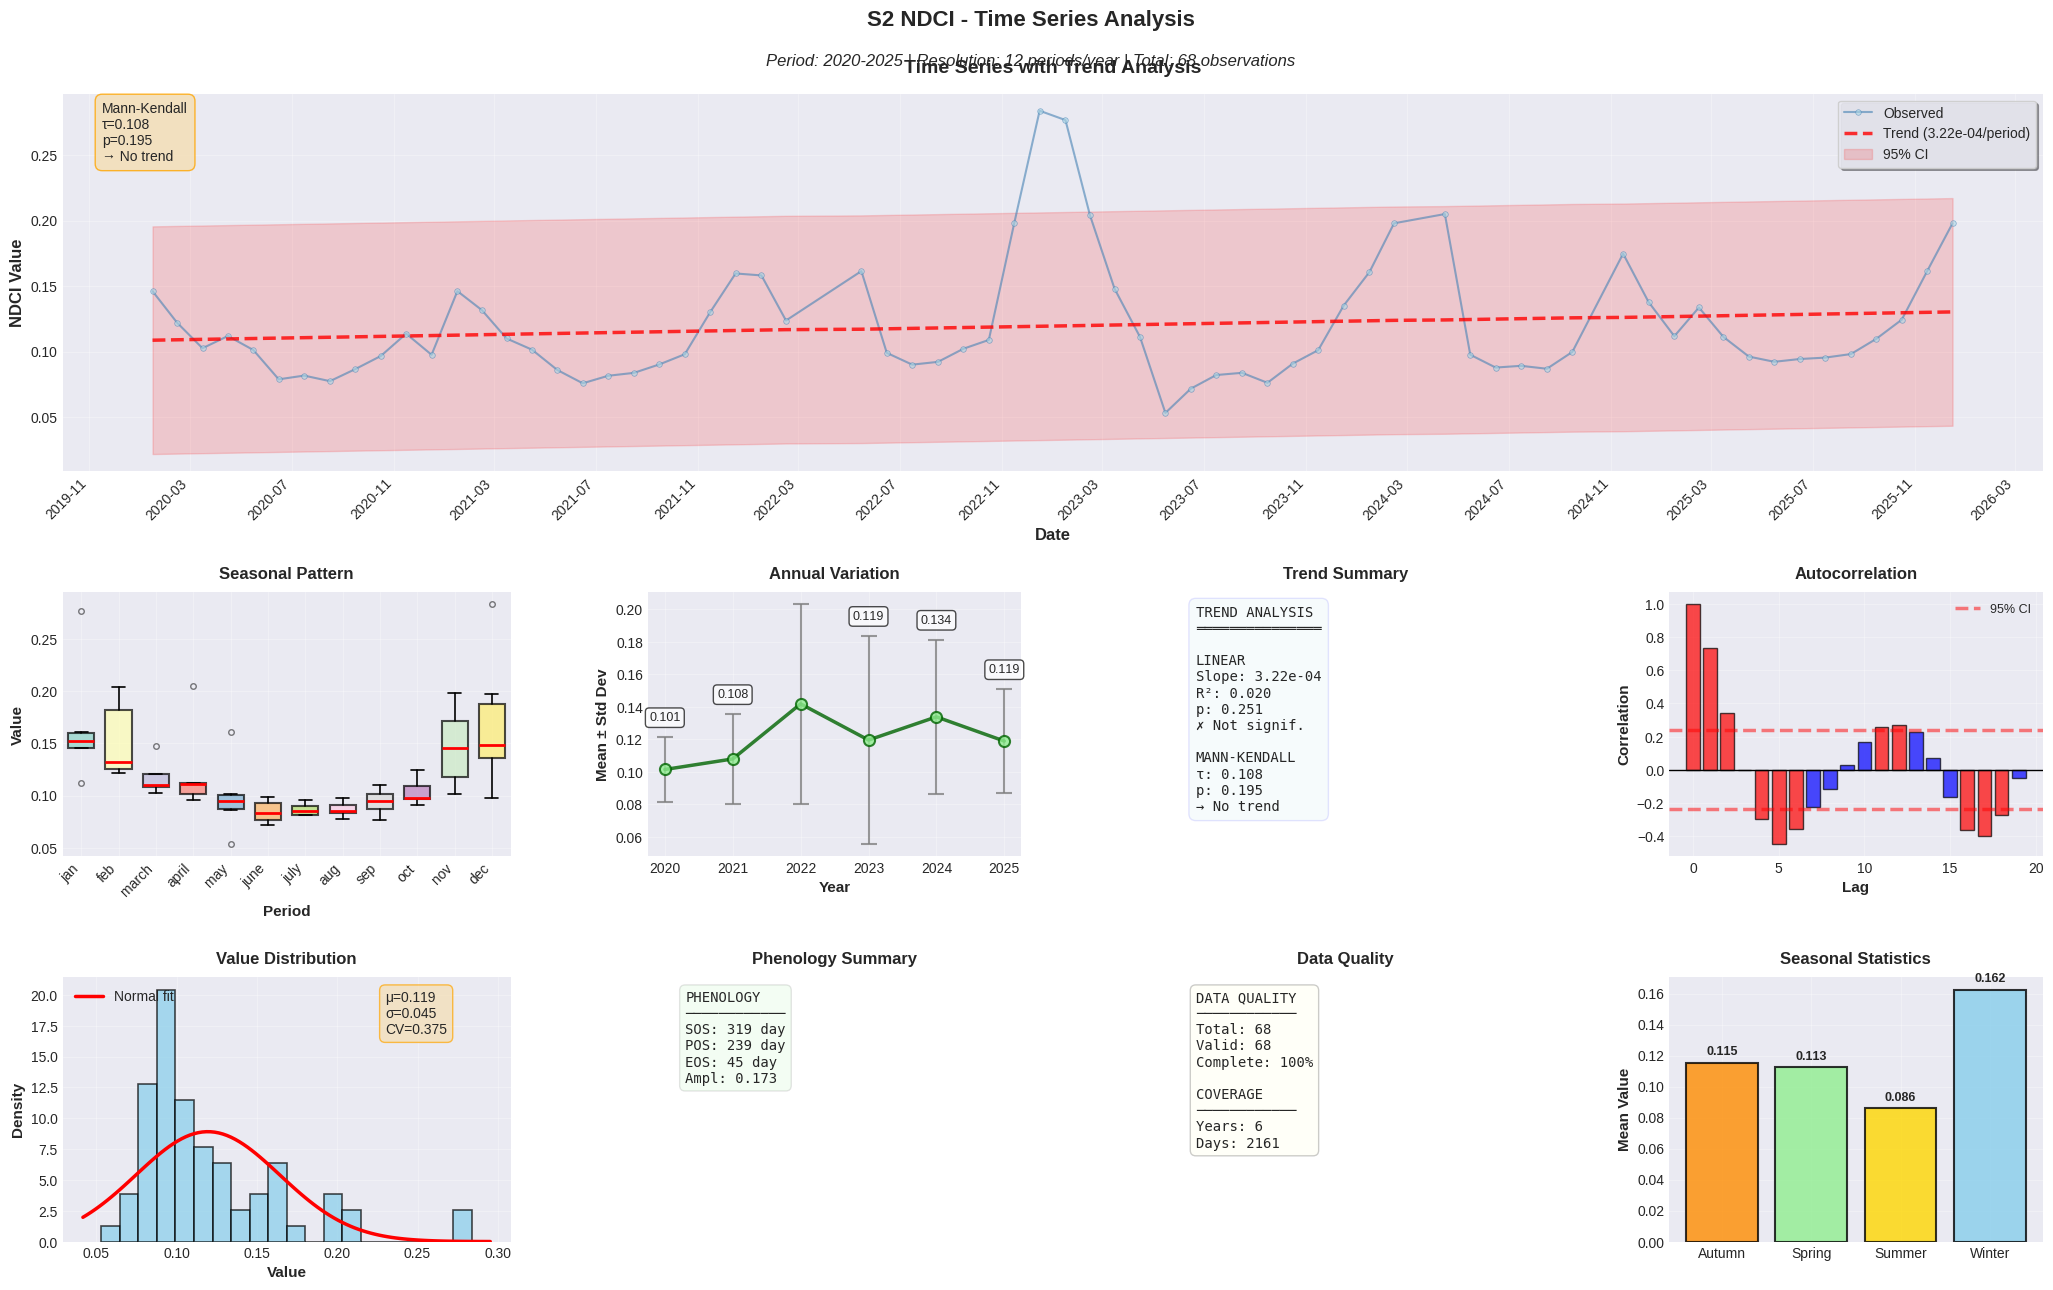

In [63]:
# Visualizacion completa de la serie temporal
ts_ndci.plot_comprehensive_analysis()

## 11. Resumen comparativo de indices de agua

Tabla resumen con los indices disponibles en ndvi2gif para monitoreo de embalses.

In [64]:
# Resumen: medias anuales de los distintos indices
print("=" * 65)
print("RESUMEN DE INDICES DE AGUA DISPONIBLES EN ndvi2gif para S2")
print("=" * 65)
print()
indices_info = [
    ("NDWI",    "ndwi",    "Deteccion agua (clasico)",               "Green/NIR",          "Todos"),
    ("MNDWI",   "mndwi",   "Deteccion agua mejorada",                "Green/SWIR1",         "Todos"),
    ("AWEInsh", "aweinsh", "Extraccion agua auto (sin sombra)",      "Blue/Green/NIR/SWIR", "Todos"),
    ("AWEI",    "awei",    "Extraccion agua auto (con sombra)",      "Blue/Green/NIR/SWIR", "Todos"),
    ("WI2015",  "wi2015",  "Indice de agua 2015",                    "NIR/SWIR1/SWIR2",     "Todos"),
    ("NDCI",    "ndci",    "Clorofila-a / cianobacterias (calidad)", "Red Edge1/Red",       "Solo S2"),
    ("NDMI",    "ndmi",    "Humedad (vegetacion acuatica/orilla)",   "NIR/SWIR1",           "Todos"),
]
print(f"{'Indice':<10} {'Clave':<10} {'Descripcion':<42} {'Bandas':<22} {'Sensores'}")
print("-" * 100)
for nombre, clave, desc, bandas, sensores in indices_info:
    print(f"{nombre:<10} {clave:<10} {desc:<42} {bandas:<22} {sensores}")

print()
print("Para indices S3 (OLCI, 300m): oci, tsi, cdom, turbidity, spm, kd490, floating_algae")

RESUMEN DE INDICES DE AGUA DISPONIBLES EN ndvi2gif para S2

Indice     Clave      Descripcion                                Bandas                 Sensores
----------------------------------------------------------------------------------------------------
NDWI       ndwi       Deteccion agua (clasico)                   Green/NIR              Todos
MNDWI      mndwi      Deteccion agua mejorada                    Green/SWIR1            Todos
AWEInsh    aweinsh    Extraccion agua auto (sin sombra)          Blue/Green/NIR/SWIR    Todos
AWEI       awei       Extraccion agua auto (con sombra)          Blue/Green/NIR/SWIR    Todos
WI2015     wi2015     Indice de agua 2015                        NIR/SWIR1/SWIR2        Todos
NDCI       ndci       Clorofila-a / cianobacterias (calidad)     Red Edge1/Red          Solo S2
NDMI       ndmi       Humedad (vegetacion acuatica/orilla)       NIR/SWIR1              Todos

Para indices S3 (OLCI, 300m): oci, tsi, cdom, turbidity, spm, kd490, floating_alg

## 12. Exportar resultados a Google Drive / GeoTIFF

Si queremos exportar las mascaras de agua para procesarlas en GIS:

In [ ]:
# Exportar la mascara de agua media interanual mensual a Google Drive
# (Descomentar para ejecutar la exportacion)

# Mediana interanual de la mascara de agua MNDWI
mascara_media = mascaras_agua.median()

# task = ee.batch.Export.image.toDrive(
#     image=mascara_media,
#     description='Mascara_agua_mensual_MNDWI',
#     folder='ndvi2gif_outputs',
#     fileNamePrefix='mascara_agua_mndwi_2020_2024',
#     region=roi_ee,
#     scale=20,
#     crs='EPSG:4326',
#     maxPixels=1e10
# )
# task.start()
# print(f"Tarea de exportacion enviada. Estado: {task.status()}")

# Exportar NDCI enmascarado
# ndci_media = composite_ndci_masked.median()
# task2 = ee.batch.Export.image.toDrive(
#     image=ndci_media,
#     description='NDCI_clorofila_mensual',
#     folder='ndvi2gif_outputs',
#     fileNamePrefix='ndci_mensual_2020_2024',
#     region=roi_ee,
#     scale=20,
#     crs='EPSG:4326',
#     maxPixels=1e10
# )
# task2.start()
# print(f"Tarea NDCI enviada. Estado: {task2.status()}")

print("Descomenta las lineas anteriores para exportar a Google Drive")

## Notas y referencias

### Indices utilizados

- **NDWI**: Gao, B. (1996). NDWI — A normalized difference water index. *Remote Sensing of Environment*, 58(3), 257–266.
- **MNDWI**: Xu, H. (2006). Modification of normalised difference water index (NDWI). *International Journal of Remote Sensing*, 27(14), 3025–3033.
- **AWEI**: Feyisa, G.L. et al. (2014). Automated Water Extraction Index: A new technique for surface water mapping. *Remote Sensing of Environment*, 140, 23–35.
- **NDCI**: Mishra, S. & Mishra, D.R. (2012). Normalized difference chlorophyll index. *Remote Sensing of Environment*, 117, 394–406.

### Umbrales recomendados para deteccion de agua

| Indice | Umbral agua | Notas |
|--------|------------|-------|
| NDWI   | > 0.0      | Puede sobreestimar agua en areas urbanas |
| MNDWI  | > 0.0      | Mas preciso en entornos heterogeneos |
| AWEInsh| > 0        | Robusto, preferible en zonas de montana |

### Interpretacion del NDCI

| NDCI | Estado del agua |
|------|----------------|
| < 0  | Agua limpia / baja clorofila |
| 0 – 0.1 | Concentracion moderada |
| 0.1 – 0.2 | Concentracion elevada (vigilar) |
| > 0.2 | Posible floracion algal (alerta) |
